<!-- [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VectorInstitute/interpretability/blob/main/implementations/Post-hoc/SHAP/shap-nn-jupyter.ipynb)
 -->
# SHAP for XG Boost Models

## **1. Introduction**

SHAP is model-agnostic and can be used to explain other black box models as well, for example, neural networks.
The shap module in python has something called KernelExplainer which can be used for NNs.

Let's illustrate this using a [Credit Card Defaulter dataset from Taiwan](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

The dataset has the following 23 variables as explanatory variables:
| Variable | Description |
|----------|------------|
| LIMIT_BAL  | Amount of the given credit (NT dollar): includes both individual consumer credit and family (supplementary) credit. |
| SEX  | Gender (1 = male; 2 = female). |
| EDUCATION  | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| MARRIAGE  | Marital status (1 = married; 2 = single; 3 = others). |
| AGE  | Age (years). |
| PAY_0  | Repayment status in September 2005 (-1 = pay duly; 1 = delay for 1 month; 2 = delay for 2 months; ...; 8 = delay for 8 months; 9 = delay for 9+ months). |
|  PAY_2 | Repayment status in August 2005. |
| PAY_3  | Repayment status in July 2005. |
| PAY_4  | Repayment status in June 2005. |
| PAY_5 | Repayment status in May 2005. |
| PAY_6 | Repayment status in April 2005. |
| BILL_AMT1 | Amount of bill statement (NT dollar) in September 2005. |
| BILL_AMT2 | Amount of bill statement (NT dollar) in August 2005. |
| BILL_AMT3 | Amount of bill statement (NT dollar) in July 2005. |
| BILL_AMT4 | Amount of bill statement (NT dollar) in June 2005. |
| BILL_AMT5 | Amount of bill statement (NT dollar) in May 2005. |
| BILL_AMT6 | Amount of bill statement (NT dollar) in April 2005. |
| PAY_AMT1 | Amount of previous payment (NT dollar) in September 2005. |
| PAY_AMT2 | Amount of previous payment (NT dollar) in August 2005. |
| PAY_AMT3 | Amount of previous payment (NT dollar) in July 2005. |
| PAY_AMT4 | Amount of previous payment (NT dollar) in June 2005. |
| PAY_AMT5 | Amount of previous payment (NT dollar) in May 2005. |
| PAY_AMT6 | Amount of previous payment (NT dollar) in April 2005. |

## **2. Import the necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import shap
import torch
import sys
!{sys.executable} -m pip install xgboost
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset


np.random.seed(1)

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## **3. Loading the dataset**

In [2]:
!pip install xgboost==1.7.6 shap==0.42.1

In [3]:
!curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
!unzip -o data/clients.zip -d data
!rm data/clients.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100 5409k    0 5409k    0     0  2286k      0 --:--:--  0:00:02 --:--:-- 2287k
Archive:  data/clients.zip
 extracting: data/default of credit card clients.xls  


In [4]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **4. Create a NumPy array**
Create a dataset class inherited from PyTorch Dataset to be input for model training.

In [5]:
# Load dataset
X = data.drop(["default payment next month", "ID"], axis=1)
y = data["default payment next month"]

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
y_train = y_train.values  # Convert pandas series to NumPy array
y_test = y_test.values

## **5. Train a XGBoost model**
Let's train a XGBoost model to predict credit card defaults.

[0]	validation_0-logloss:0.69268
[10]	validation_0-logloss:0.68805
[20]	validation_0-logloss:0.68351
[30]	validation_0-logloss:0.67906
[40]	validation_0-logloss:0.67470
[50]	validation_0-logloss:0.67042
[60]	validation_0-logloss:0.66622
[70]	validation_0-logloss:0.66210
[80]	validation_0-logloss:0.65805
[90]	validation_0-logloss:0.65408
[100]	validation_0-logloss:0.65019
[110]	validation_0-logloss:0.64636
[120]	validation_0-logloss:0.64261
[124]	validation_0-logloss:0.64112
Accuracy: 0.8193
ROC AUC Score: 0.7654


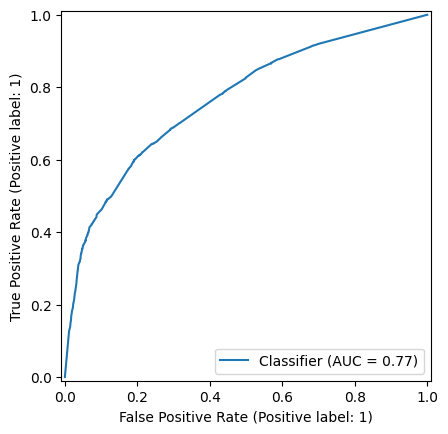

In [6]:
import xgboost as xgb

# Define the model
# - objective='binary:logistic' is the XGBoost equivalent of BCELoss + Sigmoid
# - eval_metric='logloss'       mirrors binary cross-entropy loss tracking
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=125,       # equivalent to num_epochs
    learning_rate=0.001,    # equivalent to Adam lr=0.001
    max_depth=6,
    random_state=42,
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=10,             # prints loss every 10 rounds, matching original
)

# Evaluate the model
y_pred_probs = model.predict_proba(X_test)[:, 1]  # probability of positive class
y_true = y_test

# Compute accuracy
accuracy = ((y_pred_probs > 0.5) == y_true).mean()
print(f"Accuracy: {accuracy:.4f}")

# Compute ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_true, y_pred_probs)

## **6. Use SHAP to explain XGBoost predictions**

X_test_sample shape: (50, 23)
SHAP values shape: (50, 23)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


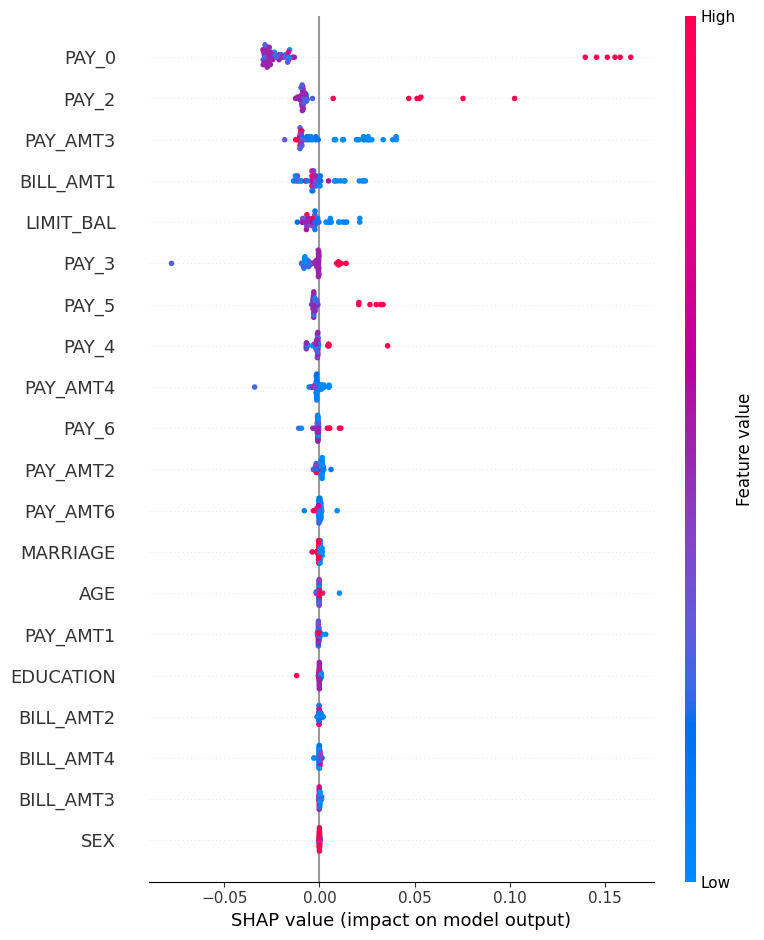

In [7]:
# Explain only a small subset of the test set (e.g., 50 samples)
X_test_sample = X_test[:50]

# Pass the booster directly to avoid XGBoost/SHAP version compatibility issue
explainer = shap.TreeExplainer(model.get_booster())

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)        # Should be (50, n_features)
print("SHAP values shape:", np.array(shap_values).shape)  # Should be (50, n_features)

# Generate SHAP summary plot
shap.summary_plot(shap_values, X_test_sample, feature_names=data.drop(["default payment next month", "ID"], axis=1).columns)

1. **What Do the Axes Mean?**
	-	Y-axis (Feature Names): Lists the most important features from top to bottom, ranked by their impact on the model’s predictions.

	-	X-axis (SHAP Value): Represents the impact of each feature on the model’s prediction.

	-	A positive SHAP value increases the probability of default.

	-	A negative SHAP value decreases the probability of default.

2. **What Do the Colors Mean?**
   
	-	Red: High feature value (e.g., high credit limit, high bill amount, etc.)

	-	Blue: Low feature value (e.g., low credit limit, low bill amount, etc.)

	-	Purple: Intermediate values.

    - If a red dot is positioned to the right, it means that a higher value of that feature increases the default risk. If it’s on the left, it decreases the risk.

3. The top-ranked features contribute the most to the model’s prediction. In this case:

	-	**PAY_0 (Repayment Status for the Most Recent Month):**
		- The most significant predictor of default.
		- Higher values (more delayed payments) strongly increase default probability (red dots shift to the right).
	 	-  Lower values (on-time payments) reduce the risk (blue dots shift left).
  
	-	**LIMIT_BAL (Credit Limit Amount):**
		- Higher credit limits seem to reduce the risk of default (red dots slightly shift left).
		-	Lower credit limits are more associated with default risk.

	-	**BILL_AMT4, BILL_AMT1, BILL_AMT6 (Bill Amounts for Different Months):**
		-	Large bill amounts have mixed impact, depending on other factors.
		-	Higher bills (red) sometimes increase default risk but not always.

	-	**PAY_4, PAY_3, PAY_2, PAY_5, PAY_6 (Previous Payment Statuses):**
		-	Late payments from earlier months also contribute to default risk.
		-	Pattern: More delays → Higher SHAP values → More risk.

4. Lesser Impact Features
   
	-	**SEX, AGE, MARRIAGE, EDUCATION:**
		-	These have much lower SHAP values, meaning they don’t significantly influence predictions.
		-	Some impact exists, but it’s much weaker than repayment history.

Credits: This notebook is taken from the [Vector Institute's 2025 Bootcamp on Interpretable and Explainable AI.](https://github.com/VectorInstitute/interpretability/tree/main)

# Reflection & Concept Check

#### 1. Thought Experiment

**How might correlated features affect SHAP interpretations?**

**Answer:**

KernelSHAP approximates Shapley values by sampling feature coalitions and implicitly assumes feature independence when marginalizing missing features.
If features are correlated (e.g., `BILL_AMT1–6`):

* Importance may be **distributed across correlated features**
* Attribution may appear diluted
* Removing one correlated feature may not change prediction much (since others substitute)

This can:

* Underestimate true causal importance
* Make rankings unstable
* Produce misleading interpretations

In financial datasets, repayment and bill history are strongly correlated, so SHAP values reflect predictive contribution under independence assumptions, not causal effect.


#### 2️. Challenge

**If you removed repayment features (`PAY_*`), what would happen to SHAP importance rankings?**

**Answer:**

Likely outcomes:

* `BILL_AMT*` and `LIMIT_BAL` would become more important.
* Demographic features might slightly increase in relative importance.
* Overall model performance (ROC AUC) would drop.

Reason:

Repayment history is the strongest predictive signal of default.
Without it, the model must rely on weaker proxies (bill amounts, credit limit).

This tests whether the model is:

* Truly learning risk patterns
* Or heavily dependent on short-term delinquency signals


#### 3️. Thought Experiment

**If background size is reduced from 200 → 20, what changes?**

**Answer:**

* Runtime decreases significantly.
* Variance of SHAP values increases.
* Summary plot may become noisier.
* Individual explanations become less stable.

Because SHAP approximates expectations over background data, fewer background samples → less accurate estimation of the expected value.


#### 4️. Challenge

**If SHAP value for `PAY_0` is +0.15, what does that mean numerically?**

**Answer:**

SHAP decomposes:

$\text{Model output} = \text{expected value} + \sum_i \phi_i$

If:

* Expected prediction = 0.32 (baseline probability)
* SHAP(PAY_0) = +0.15

Then:

PAY_0 contributes +0.15 to the predicted probability relative to the expected prediction (baseline), holding other feature contributions additive.

So prediction becomes:

$0.32 + 0.15 + \text{(other feature contributions)}$

It is not a “risk score” — it is an additive contribution relative to baseline.


#### 5️. Thought Experiment

**If you removed the sigmoid layer and computed SHAP on logits instead, what changes?**

**Answer:**

* SHAP values become additive in log-odds space (which is linear before the sigmoid transformation).
* Interpretations become more linear and stable.
* Contributions no longer bounded between 0 and 1.

Explaining logits is often mathematically cleaner because:

$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$

Additive decompositions are more natural before nonlinear squashing.

## References:
1. SHAP Documentation: [https://shap.readthedocs.io/en/latest/](https://shap.readthedocs.io/en/latest/)
2. SHAP in Interpretable Machine Learning Book: [https://christophm.github.io/interpretable-ml-book/shap.html](https://christophm.github.io/interpretable-ml-book/shap.html)
3. SHAP Original Paper: Lundberg, Scott M., and Su-In Lee. "A unified approach to interpreting model predictions." Advances in neural information processing systems 30 (2017). Link: [https://arxiv.org/abs/1705.07874](https://arxiv.org/abs/1705.07874)